# 🏥 ACL Tear Detection from MRI Scans - Complete Guide

Welcome! This notebook will guide you through building a deep learning model to detect ACL (Anterior Cruciate Ligament) tears from MRI scans.

## What You'll Learn:
1. **Data Exploration** - Understanding your MRI data
2. **Data Preprocessing** - Preparing images for the model
3. **Building a CNN Model** - Creating a neural network
4. **Training the Model** - Teaching it to detect ACL tears
5. **Evaluation** - Testing how well it works
6. **Making Predictions** - Using the model on new scans

### Key Terminology:
- **ACL** = Anterior Cruciate Ligament (a ligament in the knee)
- **MRI** = Magnetic Resonance Imaging (scan of body parts)
- **CNN** = Convolutional Neural Network (AI that's good with images)
- **ROI** = Region of Interest (the specific area we focus on)

---
## Step 1: Import Required Libraries

First, we import all the tools we need. Run this cell by pressing `Shift+Enter`.

In [2]:
# Essential libraries
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Deep learning with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# For image resizing
from skimage.transform import resize

# For progress bars
from tqdm.notebook import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available (speeds up training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
print(f"✅ PyTorch version: {torch.__version__}")

✅ Using device: cpu
✅ PyTorch version: 2.9.1+cpu


---
## Step 2: Load and Explore the Data

Let's understand what data we have. The `metadata.csv` contains information about each MRI scan.

In [3]:
# Define paths to our data
DATA_DIR = "DATASET/MRI"  # Main data folder
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")

# Load the metadata
metadata = pd.read_csv(METADATA_PATH)

print("📊 Dataset Overview:")
print(f"Total samples: {len(metadata)}")
print(f"\nColumn names: {list(metadata.columns)}")
print(f"\n{metadata.head(10)}")

📊 Dataset Overview:
Total samples: 917

Column names: ['examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename']

   examId  seriesNo  aclDiagnosis  kneeLR  roiX  roiY  roiZ  roiHeight  \
0  329637         8             0       1   139   184    14         74   
1  390116         9             0       0   113   105    10         83   
2  404663         8             1       1   120   117    15        101   
3  406320         9             0       0   117   124    12         91   
4  412857         8             0       1   122   105    14         83   
5  412865         8             1       0   111   133    13         78   
6  415102         9             0       0   116   117    11         67   
7  425707         8             0       0   113   116    11         95   
8  425713         8             0       0   108   128    13         81   
9  437474         8             0       1   107   120    12         71   

  

In [4]:
# Understanding the columns:
print("📋 Column Descriptions:")
print("""
• examId       - Unique identifier for each exam
• seriesNo     - Series number of the MRI
• aclDiagnosis - THE LABEL WE WANT TO PREDICT:
                 0 = No ACL tear (healthy)
                 1 = Partial ACL tear
                 2 = Complete ACL tear
• kneeLR       - Which knee (0=Left, 1=Right)
• roiX, roiY, roiZ - Starting position of ROI
• roiHeight, roiWidth, roiDepth - Size of ROI
• volumeFilename - Name of the .pck file containing MRI data
""")

📋 Column Descriptions:

• examId       - Unique identifier for each exam
• seriesNo     - Series number of the MRI
• aclDiagnosis - THE LABEL WE WANT TO PREDICT:
                 0 = No ACL tear (healthy)
                 1 = Partial ACL tear
                 2 = Complete ACL tear
• kneeLR       - Which knee (0=Left, 1=Right)
• roiX, roiY, roiZ - Starting position of ROI
• roiHeight, roiWidth, roiDepth - Size of ROI
• volumeFilename - Name of the .pck file containing MRI data



🔍 ACL Diagnosis Distribution:
aclDiagnosis
0    690
1    172
2     55
Name: count, dtype: int64


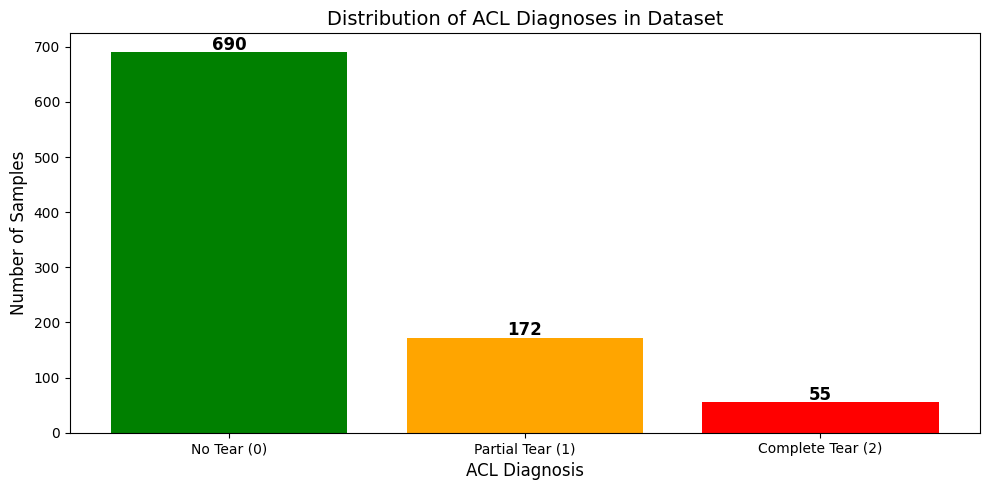


⚠️ Note: This is a class imbalance problem - we have more healthy cases than tear cases.


In [5]:
# Check the distribution of ACL diagnoses
print("🔍 ACL Diagnosis Distribution:")
diagnosis_counts = metadata['aclDiagnosis'].value_counts().sort_index()
print(diagnosis_counts)

# Visualize the distribution
plt.figure(figsize=(10, 5))
colors = ['green', 'orange', 'red']
labels = ['No Tear (0)', 'Partial Tear (1)', 'Complete Tear (2)']
bars = plt.bar(diagnosis_counts.index, diagnosis_counts.values, color=colors[:len(diagnosis_counts)])
plt.xlabel('ACL Diagnosis', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Distribution of ACL Diagnoses in Dataset', fontsize=14)
plt.xticks(diagnosis_counts.index, labels[:len(diagnosis_counts)])

# Add count labels on bars
for bar, count in zip(bars, diagnosis_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Note: This is a class imbalance problem - we have more healthy cases than tear cases.")

---
## Step 3: Examine the MRI Data Files

The `.pck` files contain 3D MRI volumes. Let's look at one to understand the structure.

In [6]:
# Function to find a .pck file in any of the volume folders
def find_pck_file(data_dir, filename):
    """Search for a .pck file in vol01 through vol08 folders"""
    for vol_num in range(1, 9):
        vol_folder = f"vol{vol_num:02d}"  # vol01, vol02, etc.
        path = os.path.join(data_dir, vol_folder, filename)
        if os.path.exists(path):
            return path
    return None

# Load one sample MRI
sample_row = metadata.iloc[0]
sample_filename = sample_row['volumeFilename']
sample_path = find_pck_file(DATA_DIR, sample_filename)

if sample_path:
    print(f"📁 Loading sample file: {sample_path}")
    with open(sample_path, 'rb') as f:
        sample_mri = pickle.load(f)
    
    print(f"\n📐 MRI Volume Shape: {sample_mri.shape}")
    print(f"   - This means: {sample_mri.shape[0]} slices, {sample_mri.shape[1]}x{sample_mri.shape[2]} pixels each")
    print(f"\n📊 Data type: {sample_mri.dtype}")
    print(f"   Value range: {sample_mri.min():.2f} to {sample_mri.max():.2f}")
else:
    print("❌ Could not find sample file. Please check your data folder structure.")

📁 Loading sample file: DATASET/MRI\vol01\329637-8.pck

📐 MRI Volume Shape: (32, 320, 320)
   - This means: 32 slices, 320x320 pixels each

📊 Data type: uint16
   Value range: 0.00 to 1529.00


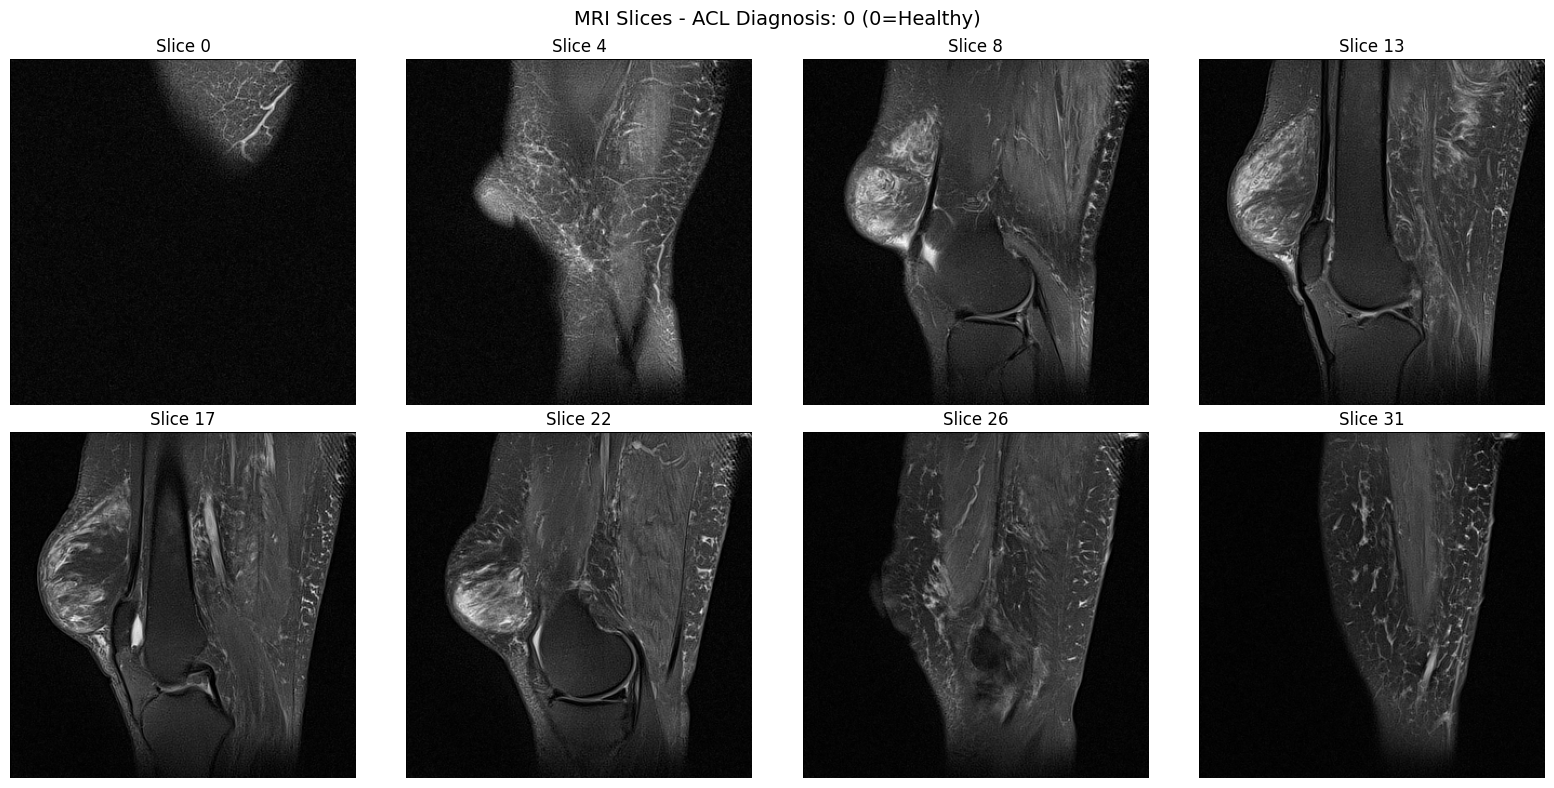

In [7]:
# Visualize slices from the MRI volume
if sample_path:
    n_slices_to_show = min(8, sample_mri.shape[0])
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    slice_indices = np.linspace(0, sample_mri.shape[0]-1, n_slices_to_show, dtype=int)
    
    for i, slice_idx in enumerate(slice_indices):
        axes[i].imshow(sample_mri[slice_idx], cmap='gray')
        axes[i].set_title(f'Slice {slice_idx}', fontsize=12)
        axes[i].axis('off')
    
    plt.suptitle(f'MRI Slices - ACL Diagnosis: {sample_row["aclDiagnosis"]} (0=Healthy)', fontsize=14)
    plt.tight_layout()
    plt.show()

📍 ROI Coordinates:
   Start: z=14, y=184, x=139
   Size:  depth=3, height=74, width=72

📐 ROI Shape: (3, 74, 72)


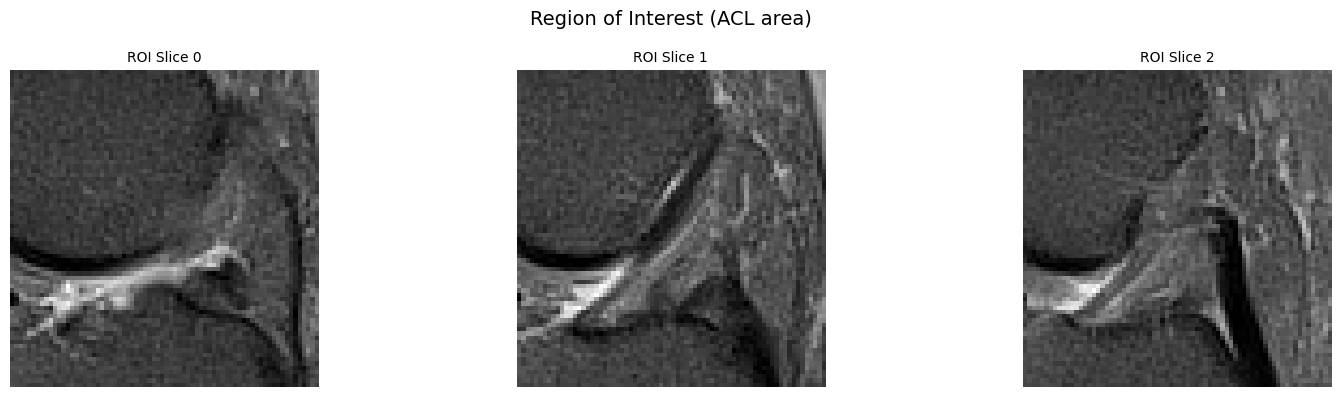

In [8]:
# Extract and visualize the Region of Interest (ROI)
if sample_path:
    # Get ROI coordinates from metadata
    z, y, x = int(sample_row['roiZ']), int(sample_row['roiY']), int(sample_row['roiX'])
    d, h, w = int(sample_row['roiDepth']), int(sample_row['roiHeight']), int(sample_row['roiWidth'])
    
    print(f"📍 ROI Coordinates:")
    print(f"   Start: z={z}, y={y}, x={x}")
    print(f"   Size:  depth={d}, height={h}, width={w}")
    
    # Extract ROI
    roi = sample_mri[z:z+d, y:y+h, x:x+w]
    print(f"\n📐 ROI Shape: {roi.shape}")
    
    # Visualize all ROI slices
    fig, axes = plt.subplots(1, min(d, 8), figsize=(16, 4))
    if d == 1:
        axes = [axes]
    
    for i in range(min(d, 8)):
        axes[i].imshow(roi[i], cmap='gray')
        axes[i].set_title(f'ROI Slice {i}', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Region of Interest (ACL area)', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Step 4: Prepare the Dataset for Training

For a binary classification (ACL tear vs no tear), we'll simplify the labels:
- **0** = No ACL tear (healthy)
- **1** = ACL tear (partial or complete)

In [8]:
# Create binary labels (0 = no tear, 1 = any tear)
metadata['binary_label'] = (metadata['aclDiagnosis'] > 0).astype(int)

print("🏷️ Binary Label Distribution:")
print(metadata['binary_label'].value_counts())
print(f"\n0 = No ACL Tear: {(metadata['binary_label'] == 0).sum()} samples")
print(f"1 = ACL Tear:    {(metadata['binary_label'] == 1).sum()} samples")

🏷️ Binary Label Distribution:
binary_label
0    690
1    227
Name: count, dtype: int64

0 = No ACL Tear: 690 samples
1 = ACL Tear:    227 samples


In [9]:
# Verify which files exist in our dataset
def check_file_exists(filename):
    return find_pck_file(DATA_DIR, filename) is not None

print("🔍 Checking which MRI files exist...")
metadata['file_exists'] = metadata['volumeFilename'].apply(check_file_exists)
valid_data = metadata[metadata['file_exists']].copy()

print(f"\n✅ Files found: {len(valid_data)} out of {len(metadata)}")
print(f"\nValid data label distribution:")
print(valid_data['binary_label'].value_counts())

🔍 Checking which MRI files exist...

✅ Files found: 736 out of 917

Valid data label distribution:
binary_label
0    547
1    189
Name: count, dtype: int64


In [10]:
# Split data into training (70%), validation (15%), and test (15%) sets
# Stratified split ensures each set has similar proportions of each class

train_df, temp_df = train_test_split(
    valid_data, 
    test_size=0.3, 
    random_state=42, 
    stratify=valid_data['binary_label']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['binary_label']
)

print("📊 Data Split:")
print(f"   Training:   {len(train_df)} samples")
print(f"   Validation: {len(val_df)} samples")
print(f"   Test:       {len(test_df)} samples")

print(f"\n📊 Label distribution in each set:")
print(f"   Training   - No Tear: {(train_df['binary_label']==0).sum()}, Tear: {(train_df['binary_label']==1).sum()}")
print(f"   Validation - No Tear: {(val_df['binary_label']==0).sum()}, Tear: {(val_df['binary_label']==1).sum()}")
print(f"   Test       - No Tear: {(test_df['binary_label']==0).sum()}, Tear: {(test_df['binary_label']==1).sum()}")

📊 Data Split:
   Training:   515 samples
   Validation: 110 samples
   Test:       111 samples

📊 Label distribution in each set:
   Training   - No Tear: 383, Tear: 132
   Validation - No Tear: 82, Tear: 28
   Test       - No Tear: 82, Tear: 29


---
## Step 5: Create the PyTorch Dataset Class

This class handles loading and preprocessing the MRI data.

In [11]:
class ACLDataset(Dataset):
    """
    Custom Dataset for ACL tear detection.
    
    This class:
    1. Loads MRI volumes from .pck files
    2. Extracts the ROI (Region of Interest)
    3. Preprocesses the data (normalize, resize)
    4. Returns tensors ready for the neural network
    """
    
    def __init__(self, dataframe, data_dir, target_size=(16, 128, 128)):
        """
        Args:
            dataframe: Pandas DataFrame with metadata
            data_dir: Path to the MRI data directory
            target_size: Desired output size (depth, height, width)
        """
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.target_size = target_size
        
    def __len__(self):
        return len(self.df)
    
    def find_file(self, filename):
        """Search for file in vol01-vol08 folders"""
        for vol_num in range(1, 9):
            vol_folder = f"vol{vol_num:02d}"
            path = os.path.join(self.data_dir, vol_folder, filename)
            if os.path.exists(path):
                return path
        return None
    
    def load_mri(self, filename):
        """Load MRI volume from .pck file"""
        path = self.find_file(filename)
        if path is None:
            raise FileNotFoundError(f"Could not find: {filename}")
        with open(path, 'rb') as f:
            return pickle.load(f)
    
    def extract_roi(self, mri, row):
        """Extract the Region of Interest from the MRI volume"""
        z = int(row['roiZ'])
        y = int(row['roiY'])
        x = int(row['roiX'])
        d = int(row['roiDepth'])
        h = int(row['roiHeight'])
        w = int(row['roiWidth'])
        return mri[z:z+d, y:y+h, x:x+w]
    
    def preprocess(self, roi):
        """Normalize and resize the ROI"""
        # Normalize to 0-1 range
        roi = roi.astype(np.float32)
        roi = (roi - roi.min()) / (roi.max() - roi.min() + 1e-8)
        
        # Resize to target size
        roi = resize(roi, self.target_size, mode='constant', 
                    anti_aliasing=True, preserve_range=True)
        
        return roi.astype(np.float32)
    
    def __getitem__(self, idx):
        """Get a single sample"""
        row = self.df.iloc[idx]
        
        # Load and process MRI
        mri = self.load_mri(row['volumeFilename'])
        roi = self.extract_roi(mri, row)
        roi = self.preprocess(roi)
        
        # Convert to tensor and add channel dimension
        # Shape: (1, depth, height, width)
        x = torch.tensor(roi).unsqueeze(0)
        
        # Get label
        y = torch.tensor(row['binary_label'], dtype=torch.float32)
        
        return x, y

print("✅ ACLDataset class defined!")

✅ ACLDataset class defined!


In [12]:
# Create datasets
TARGET_SIZE = (16, 128, 128)  # (depth, height, width)

train_dataset = ACLDataset(train_df, DATA_DIR, target_size=TARGET_SIZE)
val_dataset = ACLDataset(val_df, DATA_DIR, target_size=TARGET_SIZE)
test_dataset = ACLDataset(test_df, DATA_DIR, target_size=TARGET_SIZE)

print(f"✅ Datasets created!")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Test samples: {len(test_dataset)}")

✅ Datasets created!
   Training samples: 515
   Validation samples: 110
   Test samples: 111


In [13]:
# Test loading one sample
print("🧪 Testing dataset loading...")
sample_x, sample_y = train_dataset[0]
print(f"   Input shape: {sample_x.shape}")
print(f"   Label: {sample_y.item()} ({'ACL Tear' if sample_y.item() == 1 else 'No Tear'})")
print(f"   Input range: {sample_x.min():.3f} to {sample_x.max():.3f}")

🧪 Testing dataset loading...
   Input shape: torch.Size([1, 16, 128, 128])
   Label: 0.0 (No Tear)
   Input range: 0.000 to 0.924


In [14]:
# Create DataLoaders (batches data for training)
BATCH_SIZE = 8  # Number of samples processed together

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders created!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders created!
   Batch size: 8
   Training batches: 65
   Validation batches: 14
   Test batches: 14


---
## Step 6: Build the 3D CNN Model

We'll create a 3D Convolutional Neural Network (CNN) that can process the 3D MRI volumes.

### How it works:
1. **3D Convolutions** - Extract features from the 3D volume
2. **Batch Normalization** - Stabilize training
3. **Max Pooling** - Reduce spatial dimensions
4. **Dropout** - Prevent overfitting
5. **Fully Connected Layers** - Make the final prediction

In [15]:
class ACLDetector3D(nn.Module):
    """
    3D CNN for ACL tear detection.
    
    Architecture:
    - 4 convolutional blocks with increasing filters (32 -> 64 -> 128 -> 256)
    - Each block: Conv3D -> BatchNorm -> ReLU -> MaxPool
    - Global average pooling to flatten
    - Fully connected layers with dropout
    - Sigmoid output for binary classification
    """
    
    def __init__(self):
        super(ACLDetector3D, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 4
        self.conv4 = nn.Sequential(
            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # Global average pooling
        )
        
        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()  # Output between 0 and 1
        )
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.classifier(x)
        return x

# Create model and move to device
model = ACLDetector3D().to(device)

print("✅ Model created!")
print(f"\n📊 Model Architecture:")
print(model)

✅ Model created!

📊 Model Architecture:
ACLDetector3D(
  (conv1): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4

In [16]:
# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📊 Model Parameters:")
print(f"   Total: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")

📊 Model Parameters:
   Total: 1,204,737
   Trainable: 1,204,737


In [17]:
# Test forward pass
print("🧪 Testing forward pass...")
test_input = torch.randn(2, 1, 16, 128, 128).to(device)  # Batch of 2
test_output = model(test_input)
print(f"   Input shape: {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   Output values: {test_output.squeeze().detach().cpu().numpy()}")

🧪 Testing forward pass...
   Input shape: torch.Size([2, 1, 16, 128, 128])
   Output shape: torch.Size([2, 1])
   Output values: [0.47058475 0.4539573 ]


---
## Step 7: Define Training Components

- **Loss Function**: Binary Cross Entropy (for binary classification)
- **Optimizer**: Adam (adaptive learning rate)
- **Scheduler**: Reduces learning rate when training plateaus

In [19]:
# Calculate class weights to handle imbalanced data
n_samples = len(train_df)
n_positive = train_df['binary_label'].sum()
n_negative = n_samples - n_positive

# Give more weight to the minority class
pos_weight = torch.tensor([n_negative / n_positive]).to(device)
print(f"📊 Class weights: {pos_weight.item():.2f}")
print(f"   (Positive samples will be weighted {pos_weight.item():.2f}x more)")

# Loss function with class weights
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Note: We'll use BCEWithLogitsLoss and remove sigmoid from model's last layer
# Actually, let's use standard BCE since we have sigmoid in the model
criterion = nn.BCELoss()

# Optimizer
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"\n✅ Training components defined!")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Optimizer: Adam")
print(f"   Scheduler: ReduceLROnPlateau")

📊 Class weights: 2.90
   (Positive samples will be weighted 2.90x more)

✅ Training components defined!
   Learning rate: 0.001
   Optimizer: Adam
   Scheduler: ReduceLROnPlateau


---
## Step 8: Training Functions

These functions handle one epoch of training and validation.

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Returns:
        Average loss for the epoch
        Accuracy for the epoch
    """
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in tqdm(loader, desc="Training", leave=False):
        # Move data to device
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item() * batch_x.size(0)
        predictions = (outputs > 0.5).float()
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    """
    Validate the model.
    
    Returns:
        Average loss
        Accuracy
        All predictions and true labels
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # No gradient computation needed
        for batch_x, batch_y in tqdm(loader, desc="Validating", leave=False):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x).squeeze()
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item() * batch_x.size(0)
            predictions = (outputs > 0.5).float()
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

print("✅ Training functions defined!")

✅ Training functions defined!


---
## Step 9: Train the Model! 🚀

Now we'll train the model for multiple epochs. This will take some time depending on your hardware.

In [21]:
# Training configuration
NUM_EPOCHS = 30
PATIENCE = 7  # Stop training if no improvement for this many epochs

# Track training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Best model tracking
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f"🚀 Starting training for {NUM_EPOCHS} epochs...")
print(f"   Early stopping patience: {PATIENCE} epochs")
print("="*60)

🚀 Starting training for 30 epochs...
   Early stopping patience: 7 epochs


In [22]:
# Training loop
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc, _, _ = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"   ✅ New best model saved!")
    else:
        patience_counter += 1
        print(f"   ⚠️ No improvement for {patience_counter} epoch(s)")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("✅ Training completed!")


Epoch 1/30


Training:   0%|          | 0/65 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]

   Train Loss: 0.5880 | Train Acc: 0.7437
   Val Loss:   0.5977 | Val Acc:   0.7455
   ✅ New best model saved!

Epoch 2/30


Training:   0%|          | 0/65 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/14 [00:00<?, ?it/s]

   Train Loss: 0.4721 | Train Acc: 0.7476
   Val Loss:   0.6549 | Val Acc:   0.7455
   ⚠️ No improvement for 6 epoch(s)

Epoch 8/30


Training:   0%|          | 0/65 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]

   Train Loss: 0.4526 | Train Acc: 0.7786
   Val Loss:   0.7585 | Val Acc:   0.2818
   ⚠️ No improvement for 7 epoch(s)

⛔ Early stopping triggered after 8 epochs

✅ Training completed!


In [23]:
# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✅ Loaded best model weights")

# Save the model
MODEL_PATH = "acl_detector_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_val_loss': best_val_loss
}, MODEL_PATH)

print(f"✅ Model saved to: {MODEL_PATH}")

✅ Loaded best model weights
✅ Model saved to: acl_detector_model.pth


---
## Step 10: Visualize Training Progress

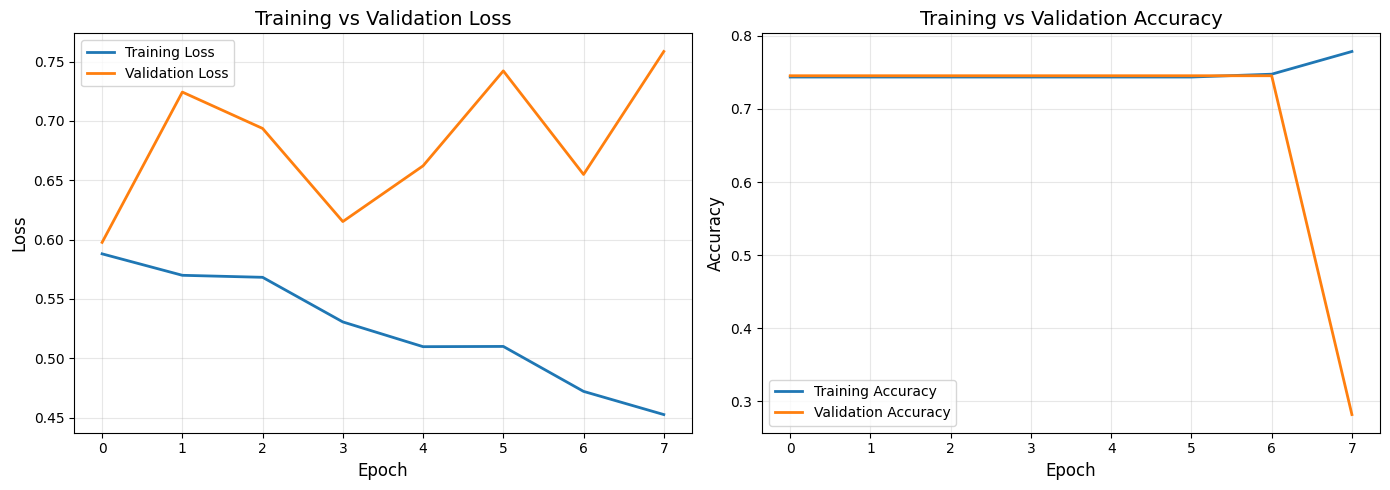


📊 Best validation loss: 0.5977
📊 Best validation accuracy: 0.7455


In [24]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Best validation loss: {best_val_loss:.4f}")
print(f"📊 Best validation accuracy: {max(history['val_acc']):.4f}")

---
## Step 11: Evaluate on Test Set

Now let's see how well our model performs on data it has never seen before!

---
## 🔄 Alternative: Load Pre-trained Model (Skip Training)

**Run this cell if you want to evaluate without retraining.** Make sure you've run:
1. Import libraries (Step 1)
2. Load metadata (Step 2)
3. Data preparation & splits (Step 4)
4. Dataset & DataLoader setup (Step 5)
5. Model definition (Step 6)
6. Define validate function (Step 8)

In [9]:
# ============================================
# LOAD PRE-TRAINED MODEL (Skip Training)
# ============================================
# Run this cell INSTEAD of the training cell if you want to 
# evaluate on the test set without retraining

MODEL_PATH = "acl_detector_model.pth"

# Check if model file exists
if os.path.exists(MODEL_PATH):
    print(f"📂 Loading model from: {MODEL_PATH}")
    
    # Load the checkpoint
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    
    # Load the model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Print info about the loaded model
    print(f"✅ Model loaded successfully!")
    if 'best_val_loss' in checkpoint:
        print(f"   Best validation loss: {checkpoint['best_val_loss']:.4f}")
    if 'history' in checkpoint:
        history = checkpoint['history']
        print(f"   Trained for {len(history['train_loss'])} epochs")
        print(f"   Best validation accuracy: {max(history['val_acc']):.4f}")
    
    print(f"\n🎯 Model is ready for evaluation on the test set!")
else:
    print(f"❌ Model file not found: {MODEL_PATH}")
    print("   Please train the model first or check the file path.")

📂 Loading model from: acl_detector_model.pth


NameError: name 'model' is not defined

In [1]:
# Evaluate on test set
print("🧪 Evaluating on test set...")
test_loss, test_acc, test_preds, test_labels = validate(
    model, test_loader, criterion, device
)

print(f"\n📊 Test Results:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

🧪 Evaluating on test set...


NameError: name 'validate' is not defined

In [26]:
# Detailed classification report
print("\n📋 Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=['No Tear', 'ACL Tear']
))


📋 Classification Report:
              precision    recall  f1-score   support

     No Tear       1.00      0.04      0.07        82
    ACL Tear       0.27      1.00      0.42        29

    accuracy                           0.29       111
   macro avg       0.63      0.52      0.25       111
weighted avg       0.81      0.29      0.16       111



In [ ]:
# Load the saved model instead of training
MODEL_PATH = "acl_detector_model.pth"
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Loaded trained model from: {MODEL_PATH}")

In [ ]:
# Load the saved model instead of training
MODEL_PATH = "acl_detector_model.pth"
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Loaded trained model from: {MODEL_PATH}")

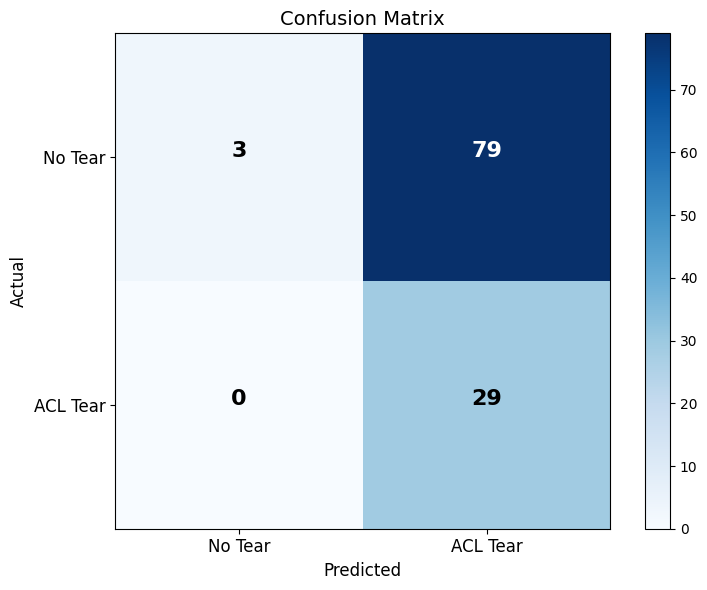


📖 Understanding the Confusion Matrix:
   True Negatives (TN):  3 - Correctly predicted No Tear
   False Positives (FP): 79 - Wrongly predicted Tear (was No Tear)
   False Negatives (FN): 0 - Wrongly predicted No Tear (was Tear)
   True Positives (TP):  29 - Correctly predicted Tear


In [27]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar()

classes = ['No Tear', 'ACL Tear']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the confusion matrix
print("\n📖 Understanding the Confusion Matrix:")
print(f"   True Negatives (TN):  {cm[0,0]} - Correctly predicted No Tear")
print(f"   False Positives (FP): {cm[0,1]} - Wrongly predicted Tear (was No Tear)")
print(f"   False Negatives (FN): {cm[1,0]} - Wrongly predicted No Tear (was Tear)")
print(f"   True Positives (TP):  {cm[1,1]} - Correctly predicted Tear")

---
## Step 12: Make Predictions on New Data

Here's how to use your trained model to predict ACL tears on new MRI scans.

In [28]:
def predict_single_scan(model, mri_path, roi_info, device):
    """
    Predict ACL tear for a single MRI scan.
    
    Args:
        model: Trained ACL detector model
        mri_path: Path to the .pck file
        roi_info: Dictionary with ROI coordinates
                  {'roiZ': z, 'roiY': y, 'roiX': x, 
                   'roiDepth': d, 'roiHeight': h, 'roiWidth': w}
        device: 'cuda' or 'cpu'
    
    Returns:
        prediction: 0 (No Tear) or 1 (Tear)
        probability: Probability of ACL tear
    """
    model.eval()
    
    # Load MRI
    with open(mri_path, 'rb') as f:
        mri = pickle.load(f)
    
    # Extract ROI
    z, y, x = roi_info['roiZ'], roi_info['roiY'], roi_info['roiX']
    d, h, w = roi_info['roiDepth'], roi_info['roiHeight'], roi_info['roiWidth']
    roi = mri[z:z+d, y:y+h, x:x+w]
    
    # Preprocess
    roi = roi.astype(np.float32)
    roi = (roi - roi.min()) / (roi.max() - roi.min() + 1e-8)
    roi = resize(roi, (16, 128, 128), mode='constant', anti_aliasing=True)
    
    # Convert to tensor
    x_tensor = torch.tensor(roi).unsqueeze(0).unsqueeze(0).float().to(device)
    
    # Predict
    with torch.no_grad():
        prob = model(x_tensor).item()
    
    prediction = 1 if prob > 0.5 else 0
    return prediction, prob

print("✅ Prediction function defined!")

✅ Prediction function defined!


In [29]:
# Example: Predict on a sample from test set
sample_idx = 0
sample_row = test_df.iloc[sample_idx]

# Get file path
sample_path = find_pck_file(DATA_DIR, sample_row['volumeFilename'])

# ROI info
roi_info = {
    'roiZ': int(sample_row['roiZ']),
    'roiY': int(sample_row['roiY']),
    'roiX': int(sample_row['roiX']),
    'roiDepth': int(sample_row['roiDepth']),
    'roiHeight': int(sample_row['roiHeight']),
    'roiWidth': int(sample_row['roiWidth'])
}

# Make prediction
prediction, probability = predict_single_scan(model, sample_path, roi_info, device)

print(f"📊 Prediction Results:")
print(f"   File: {sample_row['volumeFilename']}")
print(f"   Actual Label: {sample_row['binary_label']} ({'ACL Tear' if sample_row['binary_label'] == 1 else 'No Tear'})")
print(f"   Predicted:    {prediction} ({'ACL Tear' if prediction == 1 else 'No Tear'})")
print(f"   Confidence:   {probability:.2%}")
print(f"   Result:       {'✅ Correct!' if prediction == sample_row['binary_label'] else '❌ Incorrect'}")

📊 Prediction Results:
   File: 855548-5.pck
   Actual Label: 1 (ACL Tear)
   Predicted:    1 (ACL Tear)
   Confidence:   56.62%
   Result:       ✅ Correct!


---
## Step 13: Visualize Model Predictions

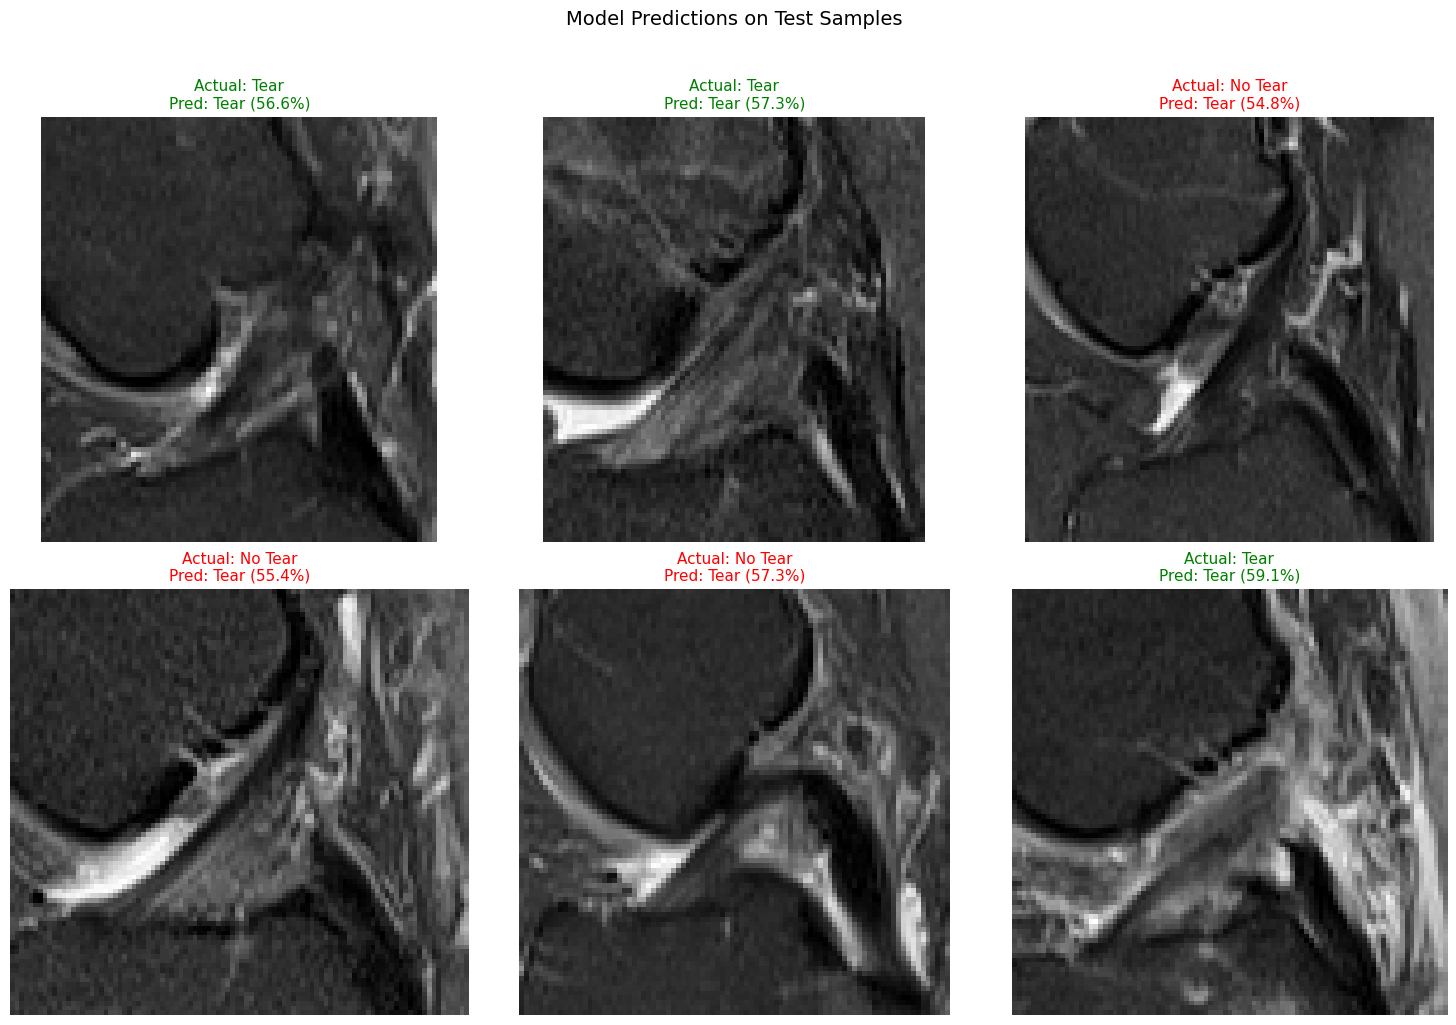

In [30]:
# Visualize predictions on multiple test samples
n_samples = min(6, len(test_df))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_samples):
    row = test_df.iloc[i]
    path = find_pck_file(DATA_DIR, row['volumeFilename'])
    
    if path:
        # Load MRI
        with open(path, 'rb') as f:
            mri = pickle.load(f)
        
        # Get ROI
        z = int(row['roiZ'])
        y = int(row['roiY'])
        x = int(row['roiX'])
        d = int(row['roiDepth'])
        h = int(row['roiHeight'])
        w = int(row['roiWidth'])
        roi = mri[z:z+d, y:y+h, x:x+w]
        
        # Make prediction
        roi_info = {'roiZ': z, 'roiY': y, 'roiX': x, 'roiDepth': d, 'roiHeight': h, 'roiWidth': w}
        pred, prob = predict_single_scan(model, path, roi_info, device)
        
        # Show middle slice of ROI
        middle_slice = roi[d//2] if d > 0 else roi[0]
        axes[i].imshow(middle_slice, cmap='gray')
        
        # Title with prediction info
        actual = 'Tear' if row['binary_label'] == 1 else 'No Tear'
        predicted = 'Tear' if pred == 1 else 'No Tear'
        color = 'green' if pred == row['binary_label'] else 'red'
        
        axes[i].set_title(
            f"Actual: {actual}\nPred: {predicted} ({prob:.1%})",
            color=color, fontsize=11
        )
        axes[i].axis('off')

plt.suptitle('Model Predictions on Test Samples', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 14: Load Model for Future Use

Here's how to load your trained model later for making predictions.

In [31]:
def load_trained_model(model_path, device):
    """
    Load a trained ACL detector model.
    
    Usage:
        model = load_trained_model('acl_detector_model.pth', device)
    """
    model = ACLDetector3D().to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded from: {model_path}")
    return model

# Example usage:
# loaded_model = load_trained_model('acl_detector_model.pth', device)

---
## 📝 Summary

Congratulations! You've successfully built an ACL tear detection model! 🎉

### What We Did:
1. **Loaded and explored** the MRI dataset
2. **Preprocessed** the 3D MRI volumes
3. **Built a 3D CNN** architecture
4. **Trained the model** with early stopping
5. **Evaluated** performance on unseen test data
6. **Made predictions** on new scans

### Files Created:
- `acl_detector_model.pth` - Your trained model
- `training_history.png` - Training progress charts
- `confusion_matrix.png` - Model performance visualization

### Next Steps to Improve:
1. **Get more data** - More training samples = better model
2. **Data augmentation** - Flip, rotate MRIs to create more training examples
3. **Try different architectures** - ResNet3D, EfficientNet3D
4. **Hyperparameter tuning** - Experiment with learning rates, batch sizes
5. **Cross-validation** - For more robust evaluation

In [32]:
print("🎉 Tutorial Complete!")
print("\nYou now have a working ACL tear detection model.")
print("Feel free to experiment and improve it!")

🎉 Tutorial Complete!

You now have a working ACL tear detection model.
Feel free to experiment and improve it!
